In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

from simulation.camera_model      import get_K, get_camera_pose
from simulation.projection        import project_points, filter_visible
from simulation.homography        import homography, decompose_H
from eight_points.eight_point_agl import eight_point
from eight_points.Retrieve_P      import get_R_t_from_epipolar, P_estimation, parallax, find_scaling_factor
from eight_points.RANSAC          import RANSAC, score_H_RANSAC, score_F_RANSAC
from pipeline.score               import score_H, score_F
from eight_points.triangulation   import triangulate

def residual_F(px1, px2, F):
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])
    # Epipolar lines
    Fx1  = F @ h1                                             # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)
    num = np.sum(h2 * Fx1, axis=0) ** 2
    denom1 = Fx1[0]**2 + Fx1[1]**2                            # (N,)
    denom2 = Ftx2[0]**2 + Ftx2[1]**2                          # (N,)
    d2_sym = num * (1.0 / (denom1 + 1e-12) + 1.0 / (denom2 + 1e-12))
    sum_d2_sym = np.sum(d2_sym)
    total_error = np.sqrt(1 / (2*N) * sum_d2_sym)
    return total_error


def make_scene(
    n_points=1000, 
    scene_type='3d', 
    x_range=2.0, 
    y_range=1.5, 
    z_min=5.0, 
    z_max=15.0,
    fx=1000.0, fy=1000.0, cx=960.0, cy=540.0, 
    img_w=1920, img_h=1080,
    cam1_rx=0.0, cam1_ry=0.0, cam1_rz=0.0, cam1_tx=0.0, cam1_ty=0.0, cam1_tz=0.0,
    cam2_rx=0.0, cam2_ry=8.0, cam2_rz=0.0, cam2_tx=1.5, cam2_ty=0, cam2_tz=0.0,
    noise_sigma=1.0, 
    outlier_ratio=0.1,
    seed=42,
    dispersion = None
):
    """
    Generates a synthetic scene seen by two cameras.
    Returns a dict: pts3d, px1, px2, K, R_rel, t_rel, R1, t1.
    """
    rng = np.random.default_rng(seed)

    # 1. Generate 3D Points
    xs = rng.uniform(-x_range, x_range, n_points)
    ys = rng.uniform(-y_range, y_range, n_points)
    if dispersion is not None:
        # 1. Generate random angles between 0 and 2π
        angles = rng.uniform(0, 2 * np.pi, n_points)
        
        # 2. Generate random radii
        # CRITICAL: You must take the square root of the random uniform value!
        # If you don't, your points will cluster heavily in the exact center.
        radii = dispersion * np.sqrt(rng.uniform(0, 1, n_points))
        
        # 3. Convert polar coordinates (radius, angle) back to Cartesian (X, Y)
        xs = radii * np.cos(angles)
        ys = radii * np.sin(angles)

    if scene_type == 'planar':
        zs = np.full(n_points, z_min)
    else:
        lo, hi = min(z_min, z_max), max(z_min, z_max)
        zs = rng.uniform(lo, hi, n_points)

    pts3d = np.vstack([xs, ys, zs])
    
    # 2. Camera Intrinsics
    K = np.array([[fx,  0, cx],
                  [ 0, fy, cy],
                  [ 0,  0,  1]], dtype=np.float64)

    # 3. Camera Poses (Extrinsics)
    R1, t1 = get_camera_pose(cam1_rx, cam1_ry, cam1_rz,
                             cam1_tx, cam1_ty, cam1_tz)
    R2, t2 = get_camera_pose(cam2_rx, cam2_ry, cam2_rz,
                             cam2_tx, cam2_ty, cam2_tz)

    R_rel = R2 @ R1.T
    t_rel = t2 - R_rel @ t1

    # 4. Project and Filter Visible Points
    px1_c, d1 = project_points(pts3d, K, R1, t1)
    px2_c, d2 = project_points(pts3d, K, R2, t2)
    
    vis = (filter_visible(px1_c, d1, img_w, img_h) &
           filter_visible(px2_c, d2, img_w, img_h))

    px1 = px1_c[:, vis].copy()
    px2 = px2_c[:, vis].copy()
    M   = px1.shape[1]

    # 5. Inject Gaussian Noise
    if noise_sigma > 0 and M > 0:
        nrng = np.random.default_rng(seed + 1000)
        px1 += nrng.normal(0, noise_sigma, px1.shape)
        px2 += nrng.normal(0, noise_sigma, px2.shape)

    # 6. Inject Outliers (False Matches)
    if outlier_ratio > 0 and M > 0:
        orng  = np.random.default_rng(seed + 2000)
        n_out = min(max(1, int(round(M * outlier_ratio))), M)
        idx   = orng.choice(M, n_out, replace=False)
        px2[0, idx] = orng.uniform(0, img_w, n_out)
        px2[1, idx] = orng.uniform(0, img_h, n_out)

    return {
        'pts3d': pts3d[:, vis], 
        'px1': px1, 
        'px2': px2,
        'K': K, 
        'R_rel': R_rel, 
        't_rel': t_rel,
        'R1': R1, 
        't1': t1,
    }

def _rot_err(R_est, R_ref):
    tr = np.trace(R_est.T @ R_ref)
    return np.degrees(np.arccos(np.clip((tr - 1) / 2, -1, 1)))


def _trans_err(t_est, t_ref):
    u = t_est / (np.linalg.norm(t_est) + 1e-12)
    v = t_ref / (np.linalg.norm(t_ref) + 1e-12)
    return np.degrees(np.arccos(np.clip(abs(np.dot(u, v)), 0, 1)))

def _trans_mag_err(t_est, t_ref):
    return np.linalg.norm(t_ref - t_est)

def get_dsamp_F(F, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])

    Fx1  = F @ h1                                              # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)

    num      = np.sum(h2 * Fx1, axis=0) ** 2                  # (x2ᵀFx1)²
    denom    = Fx1[0]**2 + Fx1[1]**2 + Ftx2[0]**2 + Ftx2[1]**2
    d_samp   = num / (denom + 1e-12)
    d_samp = np.sqrt(1 / (2 * N) * np.sum(d_samp))
    return d_samp

def get_dsamp_H(H, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])   # (3, N)
    h2 = np.vstack([px2, np.ones((1, N))])   # (3, N)

    # Forward: H · px1 → px2
    p12 = H @ h1
    p12 = p12[:2] / p12[2]
    d12 = np.sum((p12 - px2) ** 2, axis=0)

    # Backward: H⁻¹ · px2 → px1
    p21 = np.linalg.inv(H) @ h2
    p21 = p21[:2] / p21[2]
    d21 = np.sum((p21 - px1) ** 2, axis=0)
    d_samp = d12 + d21
    return d_samp

def get_angles_from_matrix(R):
    # Extract ry (theta)
    # Note: this assumes the matrix is not in a "Gimbal Lock" state (ry != 90 or -90 deg)
    ry = np.arcsin(-R[2, 0])
    
    # Extract rx (phi)
    rx = np.arctan2(R[2, 1], R[2, 2])
    
    # Extract rz (psi)
    rz = np.arctan2(R[1, 0], R[0, 0])
    
    # Convert from radians to degrees
    return np.degrees([rx, ry, rz])

def residual_H(H, px1, px2, type = "One image"):
    N = px1.shape[1]
    
    # Convert to homogeneous coordinates
    h1 = np.vstack([px1, np.ones((1, N))])   # (3, N)
    h2 = np.vstack([px2, np.ones((1, N))])   # (3, N)

    # Forward: H · px1 → px2
    p12 = H @ h1
    p12 = p12[:2] / p12[2] # Dehomogenization
    # Sum over ALL dimensions (both x/y and all N points)
    sum_d12 = np.sum((p12 - px2) ** 2) 

    if type == "One image":
        # Equation 5.1 from the textbook
        res_H = np.sqrt(1 / (2 * N) * sum_d12)
        
    else:
        # Backward: H⁻¹ · px2 → px1
        p21 = np.linalg.inv(H) @ h2
        p21 = p21[:2] / p21[2] # Dehomogenization
        sum_d21 = np.sum((p21 - px1) ** 2)
        
        # Symmetric transfer error
        res_H = np.sqrt(1 / (4 * N) * (sum_d12 + sum_d21))
        
    return res_H

In [2]:
num_iterations = 1000

angle_true = np.full((3, num_iterations), np.nan)
angle_est  = np.full((3, num_iterations), np.nan)
t_true_arr = np.full((3, num_iterations), np.nan)
t_est      = np.full((3, num_iterations), np.nan)
res_F         = np.full(num_iterations, np.nan)
R_error       = np.full(num_iterations, np.nan)
t_error       = np.full(num_iterations, np.nan)
Repro_error   = np.full(num_iterations, np.nan)
Ransac_mask   = np.full(num_iterations, np.nan)
t_error_mag_F = np.full(num_iterations, np.nan)
nb_points = 0
rx_deg = 5
ry_deg = 5
rz_deg = 5

tx = -3
ty= -3
tz = -3
for count in range(num_iterations):
    nb_points = 0
    scene_data = make_scene(n_points=1000, outlier_ratio=0.1, noise_sigma=1, cam2_rx=rx_deg, cam2_ry=ry_deg,
                                cam2_rz=  rz_deg, cam2_tx=tx, cam2_ty=ty, cam2_tz= tz, seed = count)
    pts3d_vis = scene_data['pts3d']
    px1_vis = scene_data['px1']
    px2_vis = scene_data['px2']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    R_true = scene_data['R_rel']
    t_true = scene_data['t_rel']
    nb_points = px1_vis.shape[1]
    
    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    d_samp = get_dsamp_F(F_Ransac, clean_px1, clean_px2)
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    #7 Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) # First method
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm
    P2 = K @ np.hstack((R2_hat, t2_hat))
    P1 = K@np.hstack((np.eye(3), np.zeros((3, 1))))
    pts3D_triag = triangulate(P1, P2, clean_px1, clean_px2)
    px1_hat, d1 = project_points(pts3D_triag, K, R1, t1)
    px2_hat, d2 = project_points(pts3D_triag, K, R2_hat, t2_hat)
    err1 = np.linalg.norm((clean_px1 - px1_hat), axis = 0)
    err2 = np.linalg.norm((clean_px2 - px2_hat), axis = 0)

    angle_true[:,count] = [rx_deg, ry_deg, rz_deg]
    angle_est[:,count] = get_angles_from_matrix(R2_hat)
    t_true_arr[:,count] = scene_data['t_rel'].flatten()
    t_est[:,count] = t2_hat.flatten()
    res_F[count] = residual_F(clean_px1, clean_px2, F_Ransac)
    R_error[count] = _rot_err(R2_hat, R_true)
    t_error[count] = _trans_err(t2_hat.flatten(), t_true)
    Repro_error[count] = np.mean(err1 + err2)
    Ransac_mask[count] = np.sum(mask)
    t_error_mag_F[count] = _trans_mag_err(t2_hat.flatten(), t_true)

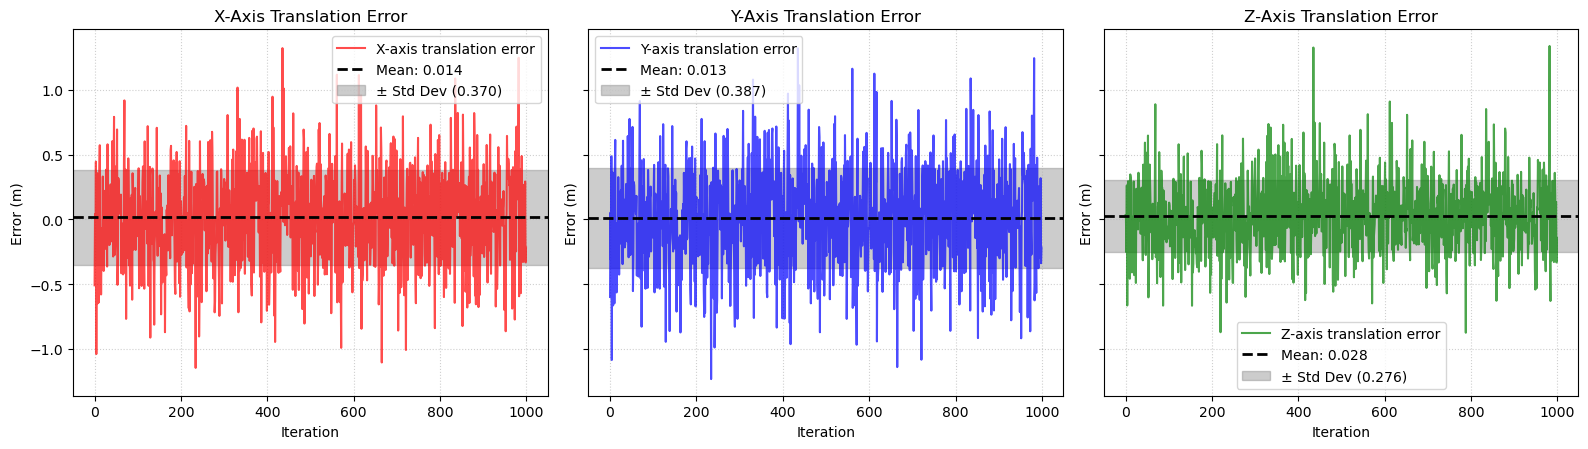

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
#fig.suptitle('Estimated Translation Error over 1000 scenes', fontsize=16)

# Labels and colors for the X, Y, Z components
components = ['X', 'Y', 'Z']
colors = ['red', 'blue', 'green'] # Red, Blue, Dark Blue

axes = [ax1, ax2, ax3]

for i in range(3):
    # Calculate the error for this specific component
    error = t_est[i, :] - t_true_arr[i, :]
    
    # Calculate Mean and Std Deviation (ignoring NaNs)
    mean_err = np.nanmean(error)
    std_err = np.nanstd(error)
    
    # Plot the raw error
    axes[i].plot(error, color=colors[i], linewidth=1.5, alpha=0.7, label=f'{components[i]}-axis translation error')
    
    # Plot the Mean as a horizontal dashed line
    axes[i].axhline(y=mean_err, color='black', linestyle='--', linewidth=2, 
                    label=f'Mean: {mean_err:.3f}')
    
    # Plot the Standard Deviation as a shaded region (Mean ± 1 Std Dev)
    axes[i].axhspan(ymin=mean_err - std_err, ymax=mean_err + std_err, 
                    color='gray', alpha=0.4, label=f'± Std Dev ({std_err:.3f})')
    
    axes[i].set_title(f'{components[i]}-Axis Translation Error')
    axes[i].set_xlabel('Scene n°')
    axes[i].set_ylabel('Error (m)')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

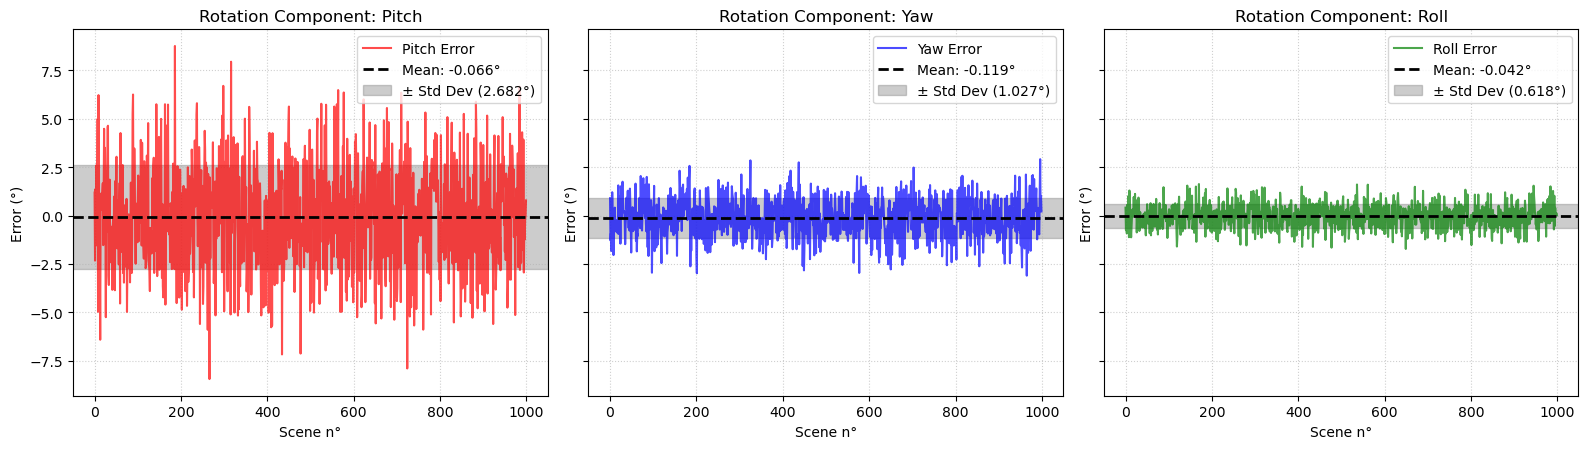

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Labels and colors for the X, Y, Z components
components = ['Pitch', 'Yaw', 'Roll']
colors = ['red', 'blue', 'green'] # Red, Blue, Dark Blue

axes = [ax1, ax2, ax3]

for i in range(3):
    # Calculate the error for this specific rotation component
    error = angle_est[i, :] - angle_true[i, :]
    
    # Calculate Mean and Std Deviation (ignoring NaNs)
    mean_err = np.nanmean(error)
    std_err = np.nanstd(error)
    
    # Plot the raw error
    axes[i].plot(error, color=colors[i], linewidth=1.5, alpha=0.7, label=f'{components[i]} Error')
    
    # Plot the Mean as a horizontal dashed line
    axes[i].axhline(y=mean_err, color='black', linestyle='--', linewidth=2, 
                    label=f'Mean: {mean_err:.3f}°')
    
    # Plot the Standard Deviation as a shaded region (Mean ± 1 Std Dev)
    axes[i].axhspan(ymin=mean_err - std_err, ymax=mean_err + std_err, 
                    color='gray', alpha=0.4, label=f'± Std Dev ({std_err:.3f}°)')
    
    # Corrected titles and labels
    axes[i].set_title(f'Rotation Component: {components[i]}')
    axes[i].set_xlabel('Scene n°')
    axes[i].set_ylabel('Error (°)')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

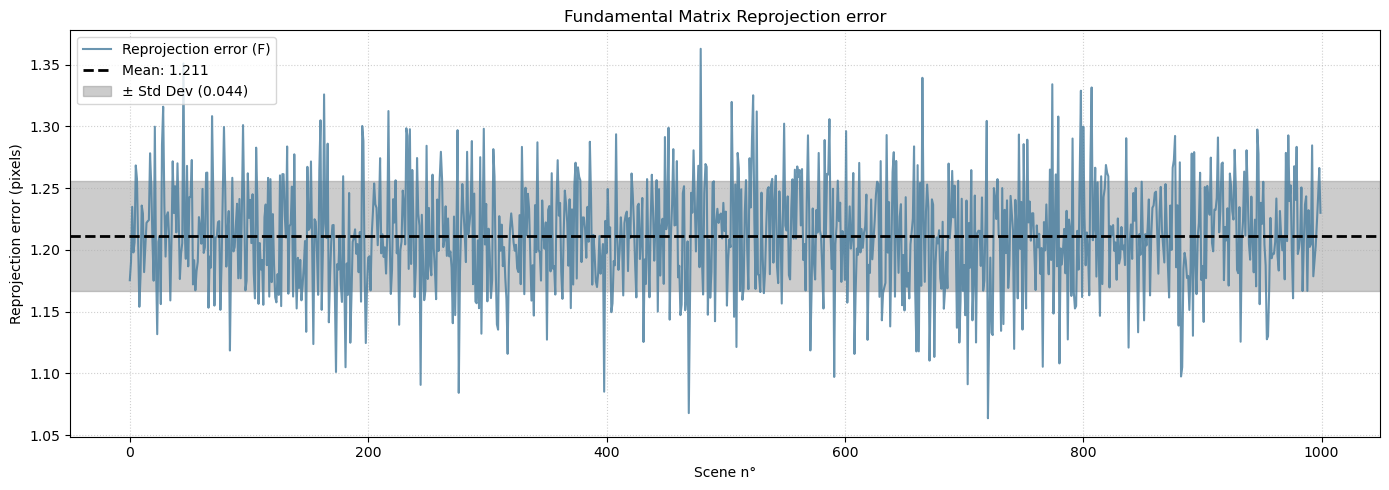

In [24]:
# ==========================================
# Figure 2: Residual Error (F matrix)
# ==========================================
plt.figure(figsize=(14, 5))

# 1. Calculate Statistics
mean_res = np.nanmean(res_F)
std_res = np.nanstd(res_F)

# 2. Plot the raw data as a solid straight line (no markers)
plt.plot(res_F, color='#457B9D', linestyle='-', linewidth=1.5, alpha=0.8, label='Reprojection error (F)')

# 3. Plot Mean and Standard Deviation
plt.axhline(y=mean_res, color='black', linestyle='--', linewidth=2, label=f'Mean: {mean_res:.3f}')
plt.axhspan(ymin=mean_res - std_res, ymax=mean_res + std_res, color='gray', alpha=0.4, label=f'± Std Dev ({std_res:.3f})')

# 4. Formatting the plot
plt.title('Fundamental Matrix Reprojection error')
plt.xlabel('Scene n°')
plt.ylabel('Reprojection error (pixels)')
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

# Homography

In [25]:
num_iterations = 1000

angle_true = np.full((3, num_iterations), np.nan)
angle_est  = np.full((3, num_iterations), np.nan)
t_true_arr = np.full((3, num_iterations), np.nan)
t_est      = np.full((3, num_iterations), np.nan)
res_H         = np.full(num_iterations, np.nan)
R_error       = np.full(num_iterations, np.nan)
t_error       = np.full(num_iterations, np.nan)
Repro_error   = np.full(num_iterations, np.nan)
Ransac_mask   = np.full(num_iterations, np.nan)
t_error_mag_H = np.full(num_iterations, np.nan)
nb_points = 0

rx_deg = 5
ry_deg = 5
rz_deg = 5

tx = -3
ty= -3
tz = -3
for count in range(num_iterations):
    nb_points = 0

    scene_data = make_scene(n_points=1000, outlier_ratio=0.1, noise_sigma=1, cam2_rx=rx_deg, cam2_ry=ry_deg,
                                cam2_rz=  rz_deg, cam2_tx=tx, cam2_ty=ty, cam2_tz= tz, scene_type="planar", seed=count, z_min=10)
    pts3d_vis = scene_data['pts3d']
    px1_vis = scene_data['px1']
    px2_vis = scene_data['px2']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    R_true = scene_data['R_rel']
    t_true = scene_data['t_rel']
    plane_dist = 10
    nb_points = px1_vis.shape[1]

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    #d_samp = get_dsamp_H(H_Ransac, clean_px1, clean_px2)
    R_H, t_H = decompose_H(H_Ransac, K, plane_dist=plane_dist,
                                    X_ref=clean_p3d[:, 0])
    P2 = K @ np.hstack((R_H, t_H.reshape(3,1)))
    P1 = K@np.hstack((np.eye(3), np.zeros((3, 1))))
    pts3D_triag = triangulate(P1, P2, clean_px1, clean_px2)
    px1_hat, d1 = project_points(pts3D_triag, K, R1, t1)
    px2_hat, d2 = project_points(pts3D_triag, K, R_H, t_H)
    err1 = np.linalg.norm((clean_px1 - px1_hat),axis = 0)
    err2 = np.linalg.norm((clean_px2 - px2_hat), axis=0)

    angle_true[:,count] = [rx_deg, ry_deg, rz_deg]
    angle_est[:,count] = get_angles_from_matrix(R_H)
    t_true_arr[:,count] = scene_data['t_rel'].flatten()
    t_est[:,count] = t_H.flatten()
    res_H[count] = residual_H(H_Ransac, clean_px1, clean_px2, type = "else")
    R_error[count] = _rot_err(R_H, R_true)
    t_error[count] = _trans_err(t_H.flatten(), t_true)
    Repro_error[count] = np.mean(err1 + err2)
    Ransac_mask[count] = np.sum(mask)
    t_error_mag_H[count] = _trans_mag_err(t_H.flatten(), t_true)

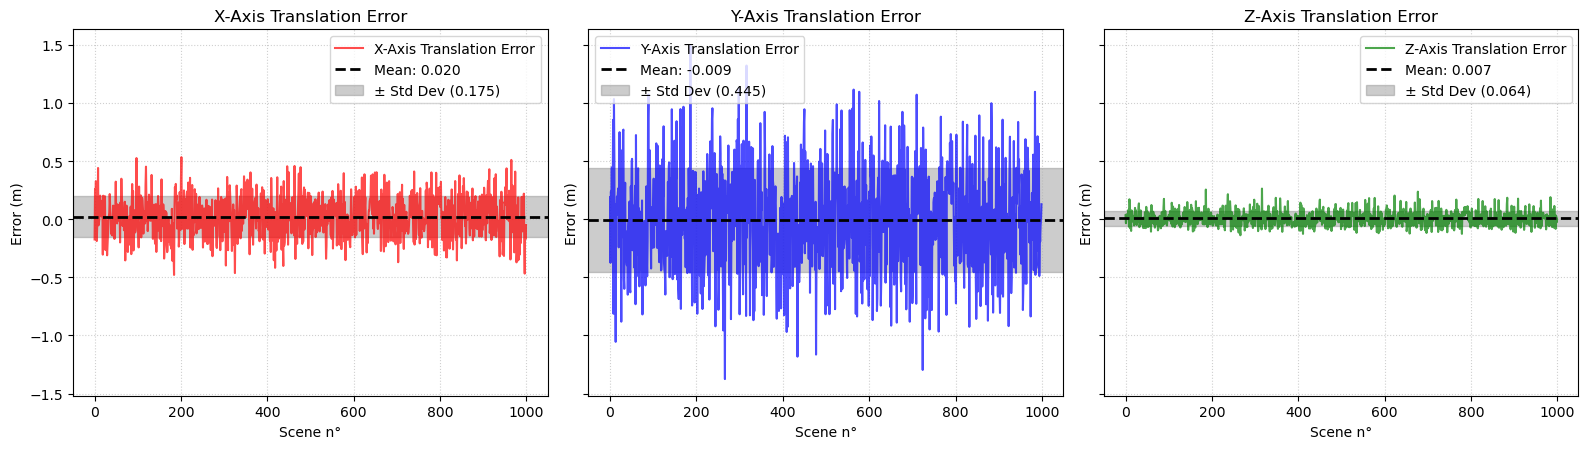

In [30]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Labels and colors for the X, Y, Z components
components = ['X', 'Y', 'Z']
colors = ['red', 'blue', 'green'] # Red, Blue, Dark Blue

axes = [ax1, ax2, ax3]

for i in range(3):
    # Calculate the error for this specific component
    error = t_est[i, :] - t_true_arr[i, :]
    
    # Calculate Mean and Std Deviation (ignoring NaNs)
    mean_err = np.nanmean(error)
    std_err = np.nanstd(error)
    
    # Plot the raw error
    axes[i].plot(error, color=colors[i], linewidth=1.5, alpha=0.7, label=f'{components[i]}-Axis Translation Error')
    
    # Plot the Mean as a horizontal dashed line
    axes[i].axhline(y=mean_err, color='black', linestyle='--', linewidth=2, 
                    label=f'Mean: {mean_err:.3f}')
    
    # Plot the Standard Deviation as a shaded region (Mean ± 1 Std Dev)
    axes[i].axhspan(ymin=mean_err - std_err, ymax=mean_err + std_err, 
                    color='gray', alpha=0.4, label=f'± Std Dev ({std_err:.3f})')
    
    axes[i].set_title(f'{components[i]}-Axis Translation Error')
    axes[i].set_xlabel('Scene n°')
    axes[i].set_ylabel('Error (m)')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

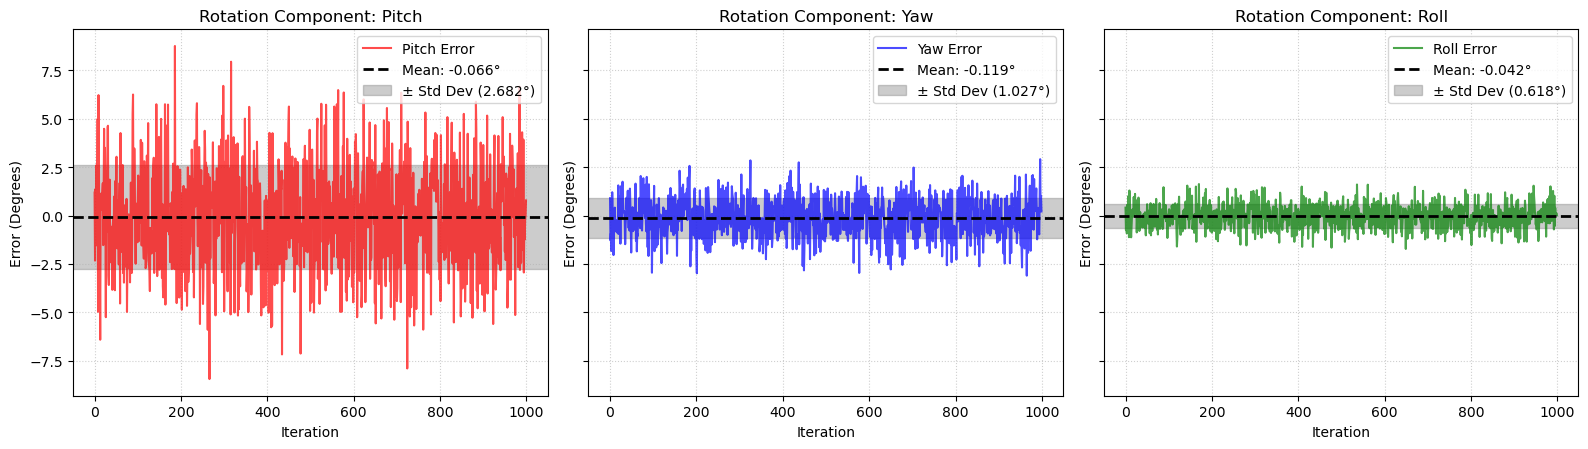

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), sharey= True)

# Labels and colors for the X, Y, Z components
components = ['Pitch', 'Yaw', 'Roll']
colors = ['red', 'blue', 'green'] # Red, Blue, Dark Blue

axes = [ax1, ax2, ax3]

for i in range(3):
    # Calculate the error for this specific rotation component
    error = angle_est[i, :] - angle_true[i, :]
    
    # Calculate Mean and Std Deviation (ignoring NaNs)
    mean_err = np.nanmean(error)
    std_err = np.nanstd(error)
    
    # Plot the raw error
    axes[i].plot(error, color=colors[i], linewidth=1.5, alpha=0.7, label=f'{components[i]} Error')
    
    # Plot the Mean as a horizontal dashed line
    axes[i].axhline(y=mean_err, color='black', linestyle='--', linewidth=2, 
                    label=f'Mean: {mean_err:.3f}°')
    
    # Plot the Standard Deviation as a shaded region (Mean ± 1 Std Dev)
    axes[i].axhspan(ymin=mean_err - std_err, ymax=mean_err + std_err, 
                    color='gray', alpha=0.4, label=f'± Std Dev ({std_err:.3f}°)')
    
    # Corrected titles and labels
    axes[i].set_title(f'Rotation Component: {components[i]}')
    axes[i].set_xlabel('Scene n°')
    axes[i].set_ylabel('Error (Degrees)')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

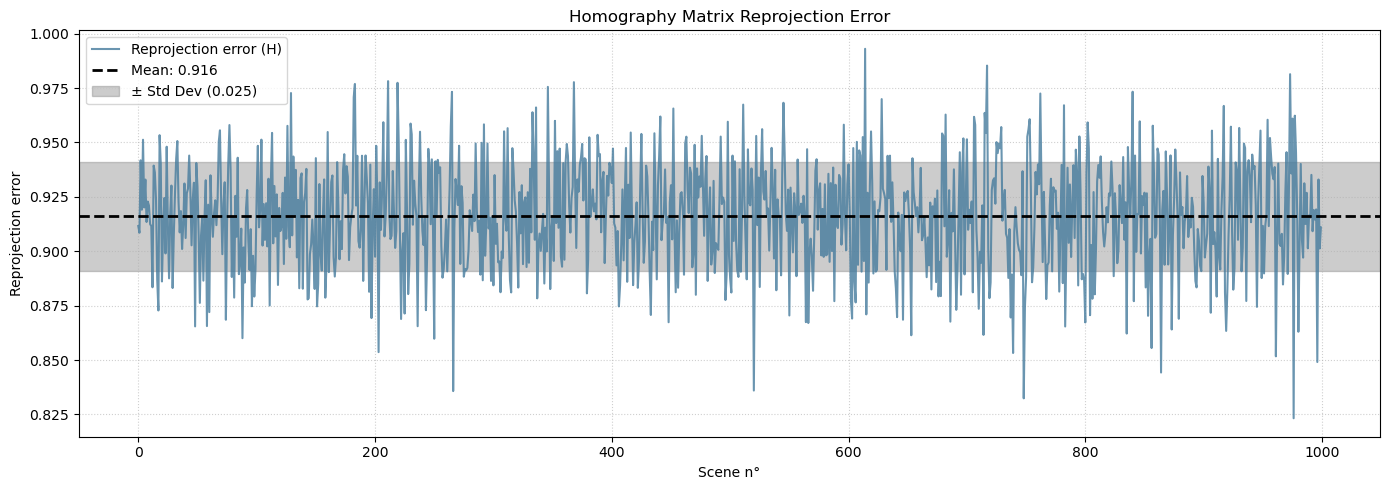

In [34]:
plt.figure(figsize=(14, 5))

# 1. Calculate Statistics
mean_res = np.nanmean(res_H)
std_res = np.nanstd(res_H)

# 2. Plot the raw data as a solid straight line (no markers)
plt.plot(res_H, color='#457B9D', linestyle='-', linewidth=1.5, alpha=0.8, label='Reprojection error (H)')

# 3. Plot Mean and Standard Deviation
plt.axhline(y=mean_res, color='black', linestyle='--', linewidth=2, label=f'Mean: {mean_res:.3f}')
plt.axhspan(ymin=mean_res - std_res, ymax=mean_res + std_res, color='gray', alpha=0.4, label=f'± Std Dev ({std_res:.3f})')

# 4. Formatting the plot
plt.title('Homography Matrix Reprojection Error')
plt.xlabel('Scene n°')
plt.ylabel('Reprojection error')
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

# Planar and None-Planar

In [69]:
num_iterations = 1000

score_ratio = np.full(num_iterations, np.nan)
angle_true = np.full((3, num_iterations), np.nan)
t_true_arr = np.full((3, num_iterations), np.nan)

res_F = np.full(num_iterations, np.nan)
R_error_F = np.full(num_iterations, np.nan)
t_error_F = np.full(num_iterations, np.nan)
t_error_mag_F = np.full(num_iterations, np.nan)
Repro_error_F = np.full(num_iterations, np.nan)
Ransac_mask_F = np.full(num_iterations, np.nan)
nb_pts_noplan = np.full(num_iterations, np.nan)
angle_est_F  = np.full((3, num_iterations), np.nan)
t_est_F      = np.full((3, num_iterations), np.nan)
d_samp = np.full(num_iterations, np.nan)

res_H = np.full(num_iterations, np.nan)
R_error_H = np.full(num_iterations, np.nan)
t_error_H = np.full(num_iterations, np.nan)
t_error_mag_H = np.full(num_iterations, np.nan)
Repro_error_H = np.full(num_iterations, np.nan)
Ransac_mask_H = np.full(num_iterations, np.nan)
nb_pts_plan = np.full(num_iterations, np.nan)
angle_est_H  = np.full((3, num_iterations), np.nan)
t_est_H      = np.full((3, num_iterations), np.nan)

prop_plan_inlier_H = np.full(num_iterations, np.nan)
prop_noplan_inlier_H = np.full(num_iterations, np.nan)

prop_plan_inlier_F = np.full(num_iterations, np.nan)
prop_noplan_inlier_F = np.full(num_iterations, np.nan)

prop_planar_noplar = np.full(num_iterations, np.nan)
Nb_points = 2000
size_window = np.full(num_iterations, np.nan)

rx_deg = 5
ry_deg = 5
rz_deg = 5

tx = -3
ty= -3
tz = -3

for count in range(num_iterations):
    nb_points = 0

    window = np.random.randint(200, 350)
        
    size_window[count] = window
    u_bound = 1000 + window
    l_bound = 700 - window
    scene_data = make_scene(n_points=Nb_points - 1650 , outlier_ratio=0, noise_sigma=1, cam2_rx=rx_deg, cam2_ry=ry_deg,
                                cam2_rz=  rz_deg, cam2_tx=tx, cam2_ty=ty, cam2_tz= tz, scene_type="planar", seed=count, x_range= 3, y_range=5, z_min=10)
    pts3d_vis = scene_data['pts3d']
    px1_planar = scene_data['px1']
    px2_planar = scene_data['px2']
    px3d_planar = scene_data['pts3d']
    scene_data = make_scene(n_points=Nb_points , outlier_ratio=0, noise_sigma=1, cam2_rx=rx_deg, cam2_ry=ry_deg,
                                cam2_rz=  rz_deg, cam2_tx=tx, cam2_ty=ty, cam2_tz= tz, seed=count, x_range=10, y_range=10)
    px1_noplanar = scene_data['px1']
    px2_noplanar = scene_data['px2']
    px3d_noplanar = scene_data['pts3d']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    R_true = scene_data['R_rel']
    t_true = scene_data['t_rel']
    inside_mask = (px1_planar[0, :] >= l_bound) & (px1_planar[0, :] <= u_bound)
    outside_mask = (px1_noplanar[0, :] <= l_bound) | (px1_noplanar[0, :] >= u_bound)

    curr_px1_planar = px1_planar[:, inside_mask]
    curr_px2_planar = px2_planar[:, inside_mask]
    curr_px3d_planar = px3d_planar[:, inside_mask]
        
    curr_px1_noplanar = px1_noplanar[:, outside_mask]
    curr_px2_noplanar = px2_noplanar[:, outside_mask]
    curr_px3d_noplanar = px3d_noplanar[:, outside_mask]

    # 3. Track the point counts
    nb_pts_plan[count] = curr_px1_planar.shape[1]
    nb_pts_noplan[count] = curr_px1_noplanar.shape[1]
    prop_planar_noplar[count] = nb_pts_plan[count]/(nb_pts_noplan[count] + nb_pts_plan[count] + 1e-8)

        # 4. Stack the temporary variables safely
    px1_combined = np.hstack((curr_px1_planar, curr_px1_noplanar))
    px2_combined = np.hstack((curr_px2_planar, curr_px2_noplanar))
    px3d_combined = np.hstack((curr_px3d_planar, curr_px3d_noplanar))
    nb_points = px1_combined.shape[1]

    t_true_arr[:,count] = scene_data['t_rel'].flatten()
    angle_true[:,count] = [rx_deg, ry_deg, rz_deg]
    plane_dist = 10

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_combined, 
        px2=px2_combined,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    n_plan = int(nb_pts_plan[count])
    
    # Count how many True values are in the planar vs non-planar halves of the mask
    inliers_plan_H = np.sum(mask[:n_plan])
    inliers_noplan_H = np.sum(mask[n_plan:])
    total_inliers_H = np.sum(mask)
    
    # Calculate the proportion of the inlier set
    prop_plan_inlier_H[count] = inliers_plan_H / total_inliers_H
    prop_noplan_inlier_H[count] = inliers_noplan_H / total_inliers_H

    clean_px1 = px1_combined[:, mask]
    clean_px2 = px2_combined[:, mask]
    clean_p3d = px3d_combined[:, mask]
    #d_samp = get_dsamp_H(H_Ransac, clean_px1, clean_px2)
    R_H, t_H = decompose_H(H_Ransac, K, plane_dist=plane_dist,
                                    X_ref=clean_p3d[:, 0])
    P2 = K @ np.hstack((R_H, t_H.reshape(3,1)))
    P1 = K@np.hstack((np.eye(3), np.zeros((3, 1))))
    pts3D_triag = triangulate(P1, P2, clean_px1, clean_px2)
    px1_hat, d1 = project_points(pts3D_triag, K, R1, t1)
    px2_hat, d2 = project_points(pts3D_triag, K, R_H, t_H)
    err1 = np.linalg.norm((clean_px1 - px1_hat),axis = 0)
    err2 = np.linalg.norm((clean_px2 - px2_hat), axis=0)
    S_H      = score_H(H_Ransac, clean_px1, clean_px2)    
    # Total symmetric reprojection error
    total_squared_errors = err1 + err2
    res_H[count] = residual_H(H_Ransac, clean_px1, clean_px2, type = "else")
    R_error_H[count] = _rot_err(R_H, R_true)
    t_error_H[count] = _trans_err(t_H.flatten(), t_true)
    t_error_mag_H[count] = _trans_mag_err(t_H.flatten(), t_true)
    Repro_error_H[count] = np.mean(err1 + err2)
    Ransac_mask_H[count] = np.sum(mask)
    t_est_H[:,count] = t_H.flatten()
    angle_est_H[:,count] = get_angles_from_matrix(R_H)

    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_combined, 
        px2=px2_combined,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()

    n_plan = int(nb_pts_plan[count])
    
    inliers_plan_F = np.sum(mask[:n_plan])
    inliers_noplan_F = np.sum(mask[n_plan:])
    total_inliers_F = np.sum(mask)
    
    prop_plan_inlier_F[count] = inliers_plan_F / total_inliers_F
    prop_noplan_inlier_F[count] = inliers_noplan_F / total_inliers_F

    clean_px1 = px1_combined[:, mask]
    clean_px2 = px2_combined[:, mask]
    clean_p3d = px3d_combined[:, mask]
    d_samp[count] = get_dsamp_F(F_Ransac, clean_px1, clean_px2)
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    #7 Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) # First method
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm
    P2 = K @ np.hstack((R2_hat, t2_hat))
    P1 = K@np.hstack((np.eye(3), np.zeros((3, 1))))
    pts3D_triag = triangulate(P1, P2, clean_px1, clean_px2)
    px1_hat, d1 = project_points(pts3D_triag, K, R1, t1)
    px2_hat, d2 = project_points(pts3D_triag, K, R2_hat, t2_hat)
    err1 = np.linalg.norm((clean_px1 - px1_hat),axis=0)
    err2 = np.linalg.norm((clean_px2 - px2_hat), axis=0)
        
    # Total symmetric reprojection error
    total_squared_errors = err1 + err2
    S_F = score_F(F_Ransac, clean_px1, clean_px2)
    res_F[count] = residual_F(clean_px1, clean_px2, F_Ransac)
    R_error_F[count] = _rot_err(R2_hat, R_true)
    t_error_F[count] = _trans_err(t2_hat.flatten(), t_true)
    Repro_error_F[count] = np.mean(err1 + err2)
    Ransac_mask_F[count] = np.sum(mask)
    t_error_mag_F[count] = _trans_mag_err(t2_hat.flatten(), t_true)
    t_est_F[:,count] = t2_hat.flatten()
    angle_est_F[:,count] = get_angles_from_matrix(R2_hat)
    score_ratio[count] = S_H / (S_H + S_F)
    print(prop_planar_noplar[count])


0.5162241887753326
0.4432132963866146
0.5611940298339942
0.48048048046605163
0.537993920956292
0.4860681114400598
0.5771604938093469
0.4757834757699207
0.4664723031933973
0.51851851850106
0.5116279069618712
0.42105263156786704
0.4615384615257819
0.4189189189075968
0.49061662197076095
0.4149484535975529
0.508571428556898
0.4356955380463072
0.43264248703542374
0.5619047618869236
0.5620915032496049
0.43478260868383745
0.48648648647187726
0.42339832867901395
0.47777777776450614
0.5181058495677408
0.4942528735490157
0.45961002784235067
0.5203252032379315
0.49279538903478975
0.5258620689504062
0.46556473827918554
0.48022598868699923
0.4628571428439184
0.4564102563985536
0.5078369905796917
0.49865951741290454
0.4452736318297196
0.45730027546949586
0.5328947368245758
0.5061349693096278
0.5947712418106283
0.5714285714104308
0.5232198142252873
0.4741379310208581
0.48941798940504183
0.43002544528167874
0.4830508474439816
0.47147147145731316
0.5358361774561148
0.46791443849016273
0.423469387744299

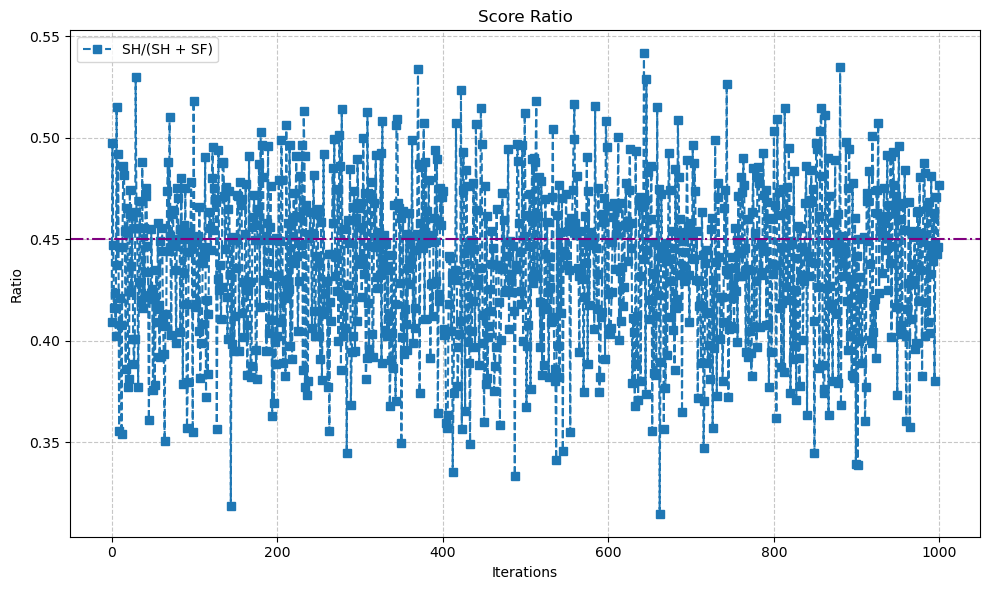

In [59]:
plt.figure(figsize=(10, 6))

# Plot the four error metrics against the noise_sigmas
plt.plot(score_ratio, label='SH/(SH + SF)', marker='s', linestyle='--')
plt.axhline(y=0.45, color='purple', linestyle='-.')

# Formatting the plot
plt.title('Score Ratio')
plt.xlabel('Iterations')
plt.ylabel('Ratio')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

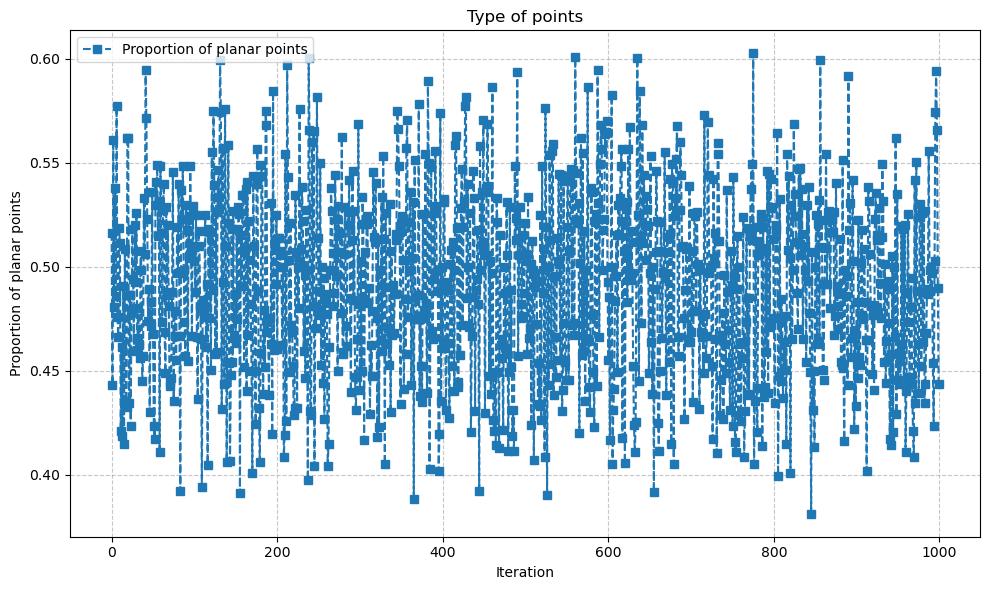

In [70]:
plt.figure(figsize=(10, 6))

# Plot the four error metrics against the noise_sigmas

plt.plot(prop_planar_noplar , label='Proportion of planar points', marker='s', linestyle='--')

# Formatting the plot
plt.title('Type of points')
plt.xlabel('Iteration')
plt.ylabel('Proportion of planar points')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()


<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\thien\AppData\Local\Temp\ipykernel_9644\200553951.py:23: SyntaxWarning: invalid escape sequence '\p'
  color='red', alpha=0.15, label=f'Std: $\pm${std_prop:.3f}')


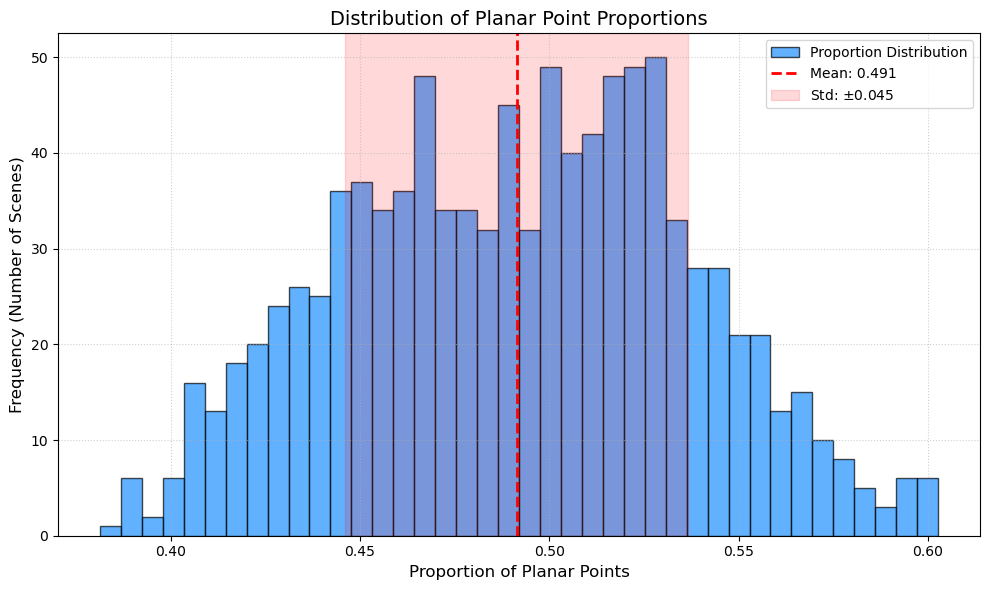

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Filter out NaNs (best practice based on your previous arrays)
valid_prop = prop_planar_noplar[~np.isnan(prop_planar_noplar)]

# 2. Calculate Stats
mean_prop = np.mean(valid_prop)
std_prop = np.std(valid_prop)

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Plot the histogram (adjust 'bins' if you want thinner/wider bars)
plt.hist(valid_prop, bins=40, color='dodgerblue', edgecolor='black', alpha=0.7, label='Proportion Distribution')

# Plot Mean as a vertical dashed line
plt.axvline(x=mean_prop, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_prop:.3f}')

# Plot Standard Deviation as a vertical shaded region
plt.axvspan(xmin=mean_prop - std_prop, xmax=mean_prop + std_prop, 
            color='red', alpha=0.15, label=f'Std: $\pm${std_prop:.3f}')

# Formatting
plt.title('Distribution of Planar Point Proportions', fontsize=14)
plt.xlabel('Proportion of Planar Points', fontsize=12)
plt.ylabel('Frequency (Number of Scenes)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
C:\Users\thien\AppData\Local\Temp\ipykernel_9644\2240744863.py:21: SyntaxWarning: invalid escape sequence '\p'
  color='red', alpha=0.20, label=f'F Std: $\pm${std_F:.4f}')
C:\Users\thien\AppData\Local\Temp\ipykernel_9644\2240744863.py:29: SyntaxWarning: invalid escape sequence '\p'
  color='blue', alpha=0.20, label=f'H Std: $\pm${std_H:.4f}')


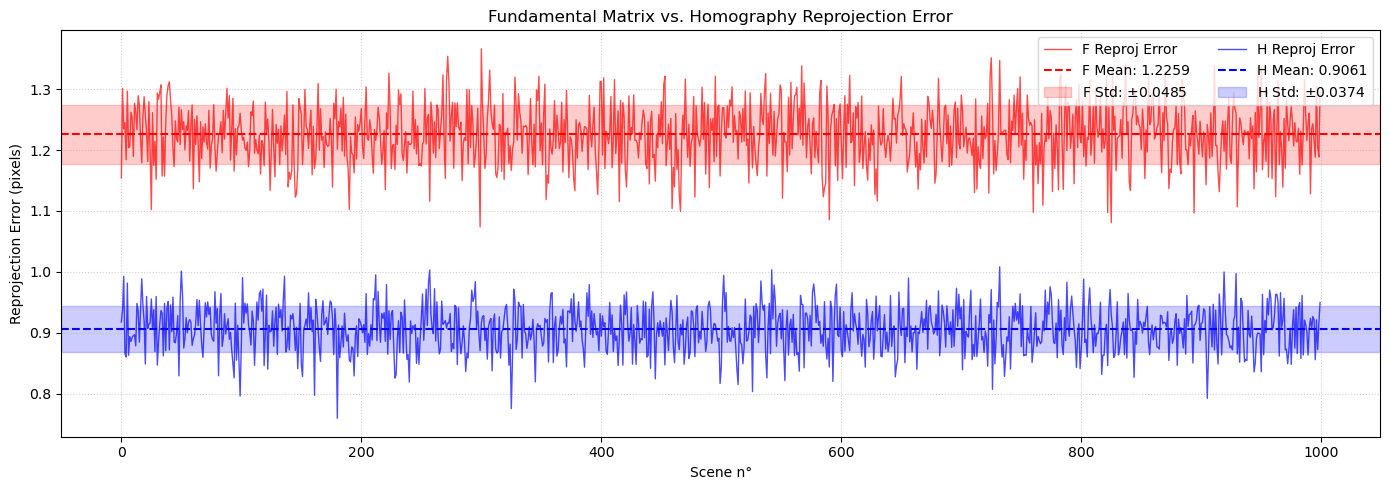

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Filter NaNs
valid_res_F = res_F[~np.isnan(res_F)]
valid_res_H = res_H[~np.isnan(res_H)]

# 2. Calculate Stats (using the valid arrays to avoid NaN results)
mean_F, std_F = np.mean(valid_res_F), np.std(valid_res_F)
mean_H, std_H = np.mean(valid_res_H), np.std(valid_res_H)

# 3. Create a Single Plot
fig, ax = plt.subplots(figsize=(14, 5))

# --- Plot Fundamental Matrix (F) Residuals ---
ax.plot(res_F, color='red', linewidth=1, alpha=0.7, label='F Reproj Error')
ax.axhline(mean_F, color='red', linestyle='--', linewidth=1.5, label=f'F Mean: {mean_F:.4f}')

# Shaded box for Std Dev (Fundamental)
ax.axhspan(mean_F - std_F, mean_F + std_F, 
           color='red', alpha=0.20, label=f'F Std: $\pm${std_F:.4f}')

# --- Plot Homography (H) Residuals ---
ax.plot(res_H, color='blue', linewidth=1, alpha=0.7, label='H Reproj Error')
ax.axhline(mean_H, color='blue', linestyle='--', linewidth=1.5, label=f'H Mean: {mean_H:.4f}')

# Shaded box for Std Dev (Homography)
ax.axhspan(mean_H - std_H, mean_H + std_H, 
           color='blue', alpha=0.20, label=f'H Std: $\pm${std_H:.4f}')

ax.set_title('Fundamental Matrix vs. Homography Reprojection Error')
ax.set_xlabel('Scene n°')
ax.set_ylabel('Reprojection Error (pixels)')
ax.grid(True, linestyle=':', alpha=0.6)

# Organize legend into 2 columns so it doesn't block too much data
ax.legend(loc='upper right', ncol=2) 

plt.tight_layout()
plt.show()


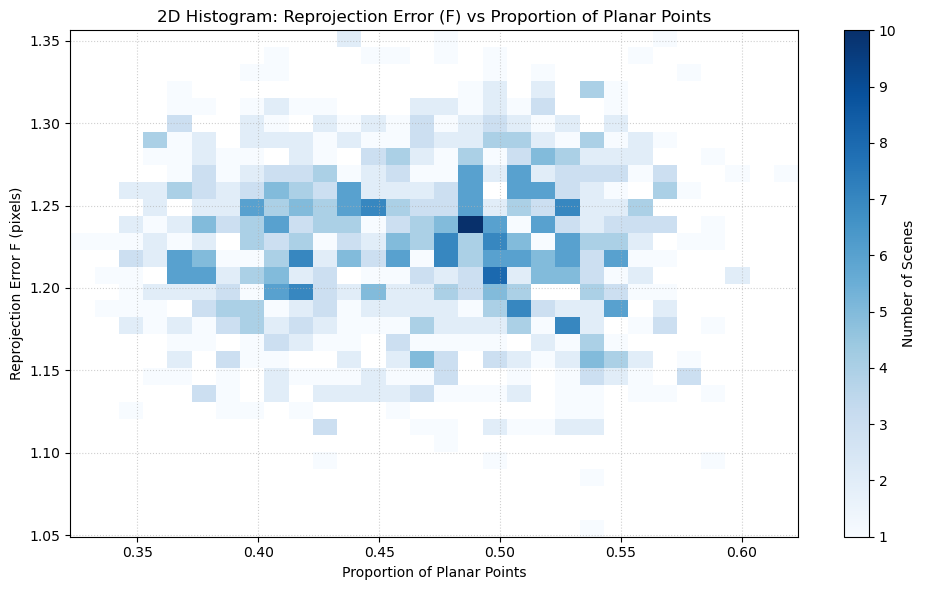

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Filter out NaNs from both arrays simultaneously to keep them aligned
valid_mask = ~np.isnan(res_F) & ~np.isnan(prop_planar_noplar)
valid_F = res_F[valid_mask]
valid_ratio = prop_planar_noplar[valid_mask]

# 2. Create the 2D Histogram
plt.figure(figsize=(10, 6))
h = plt.hist2d(prop_planar_noplar, valid_F, bins=(30, 30), cmap='Blues', cmin=1)

# Add a colorbar to show the density count
plt.colorbar(h[3], label='Number of Scenes')

plt.title('2D Histogram: Reprojection Error (F) vs Proportion of Planar Points')
plt.xlabel('Proportion of Planar Points')
plt.ylabel('Reprojection Error F (pixels)')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

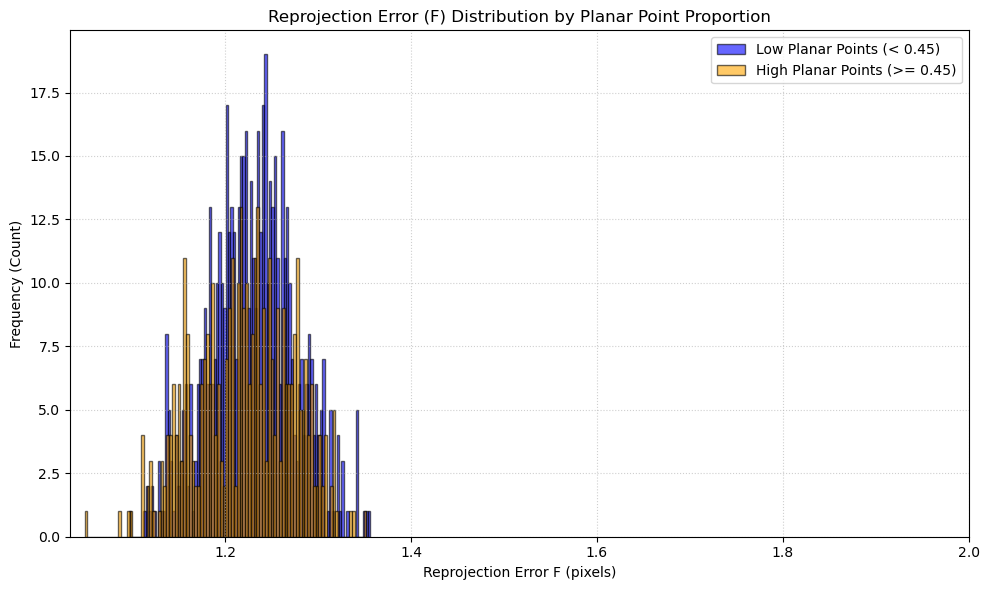

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Filter out NaNs
valid_mask = ~np.isnan(res_F) & ~np.isnan(score_ratio)
valid_F = res_F[valid_mask]
valid_ratio = score_ratio[valid_mask]

# 2. Split the errors based on a proportion threshold (e.g., 0.45)
threshold = 0.45
low_planar_F = valid_F[valid_ratio < threshold]
high_planar_F = valid_F[valid_ratio >= threshold]

# 3. Plot overlapping histograms
plt.figure(figsize=(10, 6))

plt.hist(low_planar_F, bins=100, alpha=0.6, color='blue', edgecolor='black', 
         label=f'Low Planar Points (< {threshold})')
plt.hist(high_planar_F, bins=100, alpha=0.6, color='orange', edgecolor='black', 
         label=f'High Planar Points (>= {threshold})')

plt.title('Reprojection Error (F) Distribution by Planar Point Proportion')
plt.xlabel('Reprojection Error F (pixels)')
plt.ylabel('Frequency (Count)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Optional: zoom in on the main cluster if there are massive outliers
plt.xlim(right=2.0) 

plt.tight_layout()
plt.show()

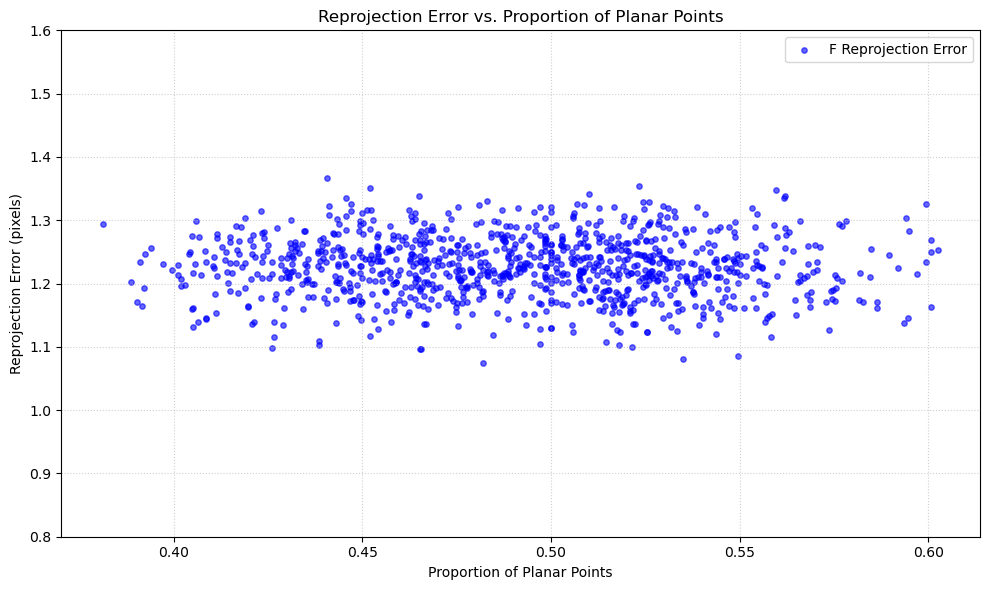

[0.51622419 0.4432133  0.56119403 0.48048048 0.53799392 0.48606811
 0.57716049 0.47578348 0.4664723  0.51851852 0.51162791 0.42105263
 0.46153846 0.41891892 0.49061662 0.41494845 0.50857143 0.43569554
 0.43264249 0.56190476 0.5620915  0.43478261 0.48648649 0.42339833
 0.47777778 0.51810585 0.49425287 0.45961003 0.5203252  0.49279539
 0.52586207 0.46556474 0.48022599 0.46285714 0.45641026 0.50783699
 0.49865952 0.44527363 0.45730028 0.53289474 0.50613497 0.59477124
 0.57142857 0.52321981 0.47413793 0.48941799 0.43002545 0.48305085
 0.47147147 0.53583618 0.46791444 0.42346939 0.41734417 0.540625
 0.5297619  0.54878049 0.51470588 0.5316092  0.41081081 0.5487013
 0.51622419 0.4735376  0.52715655 0.54       0.46865672 0.44875346
 0.52857143 0.48656716 0.52012384 0.48115942 0.44444444 0.44274809
 0.44657534 0.48793566 0.54545455 0.43569554 0.47883598 0.46666667
 0.45528455 0.51895044 0.49712644 0.53968254 0.46666667 0.39230769
 0.53714286 0.52285714 0.54861111 0.49853372 0.47340426 0.4573643

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Filter out NaNs to ensure X and Y arrays match perfectly
valid_mask = ~np.isnan(res_F) & ~np.isnan(prop_planar_noplar)
x_data = prop_planar_noplar[valid_mask]
y_data_F = res_F[valid_mask]

# 2. Create the scatter plot
plt.figure(figsize=(10, 6))

# s=15 controls dot size, alpha=0.6 makes them slightly transparent
plt.scatter(x_data, y_data_F, alpha=0.6, s=15, color='blue', label='F Reprojection Error')

plt.title('Reprojection Error vs. Proportion of Planar Points')
plt.xlabel('Proportion of Planar Points')
plt.ylabel('Reprojection Error (pixels)')
plt.grid(True, linestyle=':', alpha=0.6)

# Applying your previous Y-axis cap to hide extreme outliers
plt.ylim(bottom=0.8, top=1.6) 

plt.legend()
plt.tight_layout()
plt.show()
print(prop_planar_noplar)

<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
C:\Users\thien\AppData\Local\Temp\ipykernel_9644\1399270598.py:37: SyntaxWarning: invalid escape sequence '\p'
  ax_F.text(0.05, 0.95, f'Mean: {mean_F:.3f}°\nStd: $\pm${std_F:.3f}°',
C:\Users\thien\AppData\Local\Temp\ipykernel_9644\1399270598.py:62: SyntaxWarning: invalid escape sequence '\p'
  ax_H.text(0.05, 0.95, f'Mean: {mean_H:.3f}°\nStd: $\pm${std_H:.3f}°',


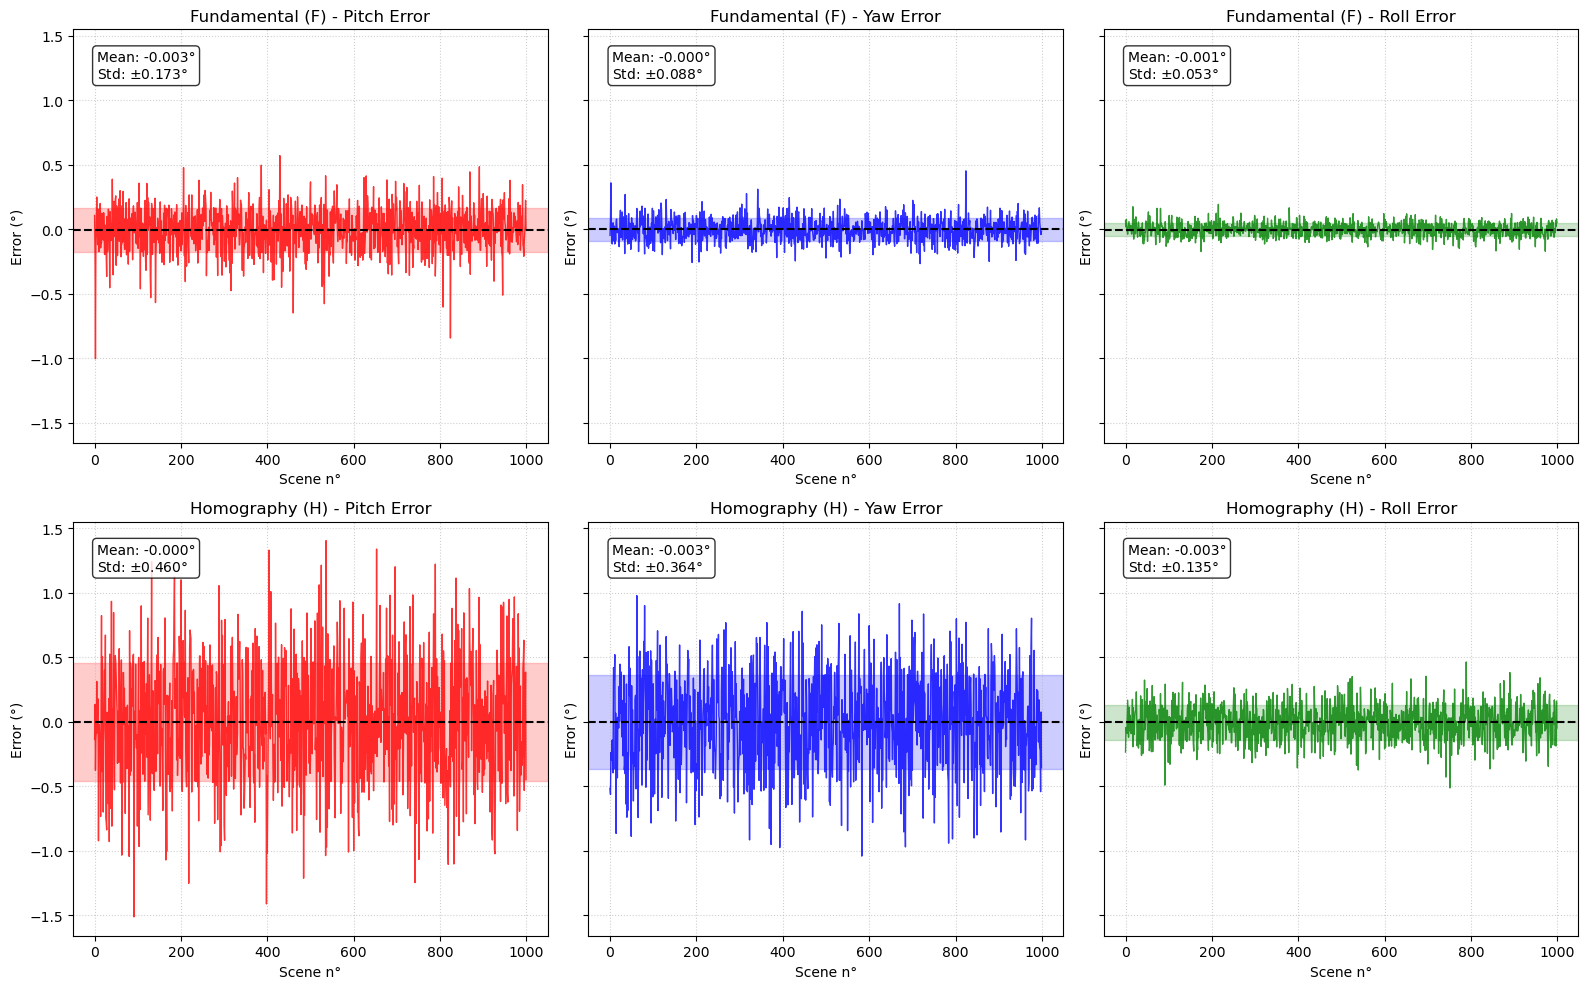

In [88]:
# 1. Calculate the error for each angle (Estimated - True)
# Both arrays are shape (3, num_iterations)
err_angle_F = angle_est_F - angle_true
err_angle_H = angle_est_H - angle_true

# 2. Set up a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

labels = ['Pitch', 'Yaw', 'Roll']
colors_F = ['red', 'blue', 'green']
colors_H = ['red', 'blue', 'green']

# Loop through the 3 axes (rx=0, ry=1, rz=2)
for i in range(3):
    
    # ==========================================
    # ROW 1: FUNDAMENTAL MATRIX (F)
    # ==========================================
    ax_F = axes[0, i]
    
    # Filter NaNs for this specific axis
    valid_err_F = err_angle_F[i, ~np.isnan(err_angle_F[i])]
    mean_F, std_F = np.mean(valid_err_F), np.std(valid_err_F)
    
    # Plot
    ax_F.plot(err_angle_F[i], color=colors_F[i], linewidth=1, alpha=0.8)
    ax_F.axhline(mean_F, color='black', linestyle='--', linewidth=1.5)
    ax_F.axhspan(mean_F - std_F, mean_F + std_F, color=colors_F[i], alpha=0.2)
    
    # Formatting
    ax_F.set_title(f'Fundamental (F) - {labels[i]} Error')
    ax_F.set_xlabel('Scene n°')
    ax_F.set_ylabel('Error (°)')
    ax_F.grid(True, linestyle=':', alpha=0.6)
    
    # Stats Text Box
    ax_F.text(0.05, 0.95, f'Mean: {mean_F:.3f}°\nStd: $\pm${std_F:.3f}°', 
              transform=ax_F.transAxes, verticalalignment='top', 
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # ==========================================
    # ROW 2: HOMOGRAPHY MATRIX (H)
    # ==========================================
    ax_H = axes[1, i]
    
    # Filter NaNs for this specific axis
    valid_err_H = err_angle_H[i, ~np.isnan(err_angle_H[i])]
    mean_H, std_H = np.mean(valid_err_H), np.std(valid_err_H)
    
    # Plot
    ax_H.plot(err_angle_H[i], color=colors_H[i], linewidth=1, alpha=0.8)
    ax_H.axhline(mean_H, color='black', linestyle='--', linewidth=1.5)
    ax_H.axhspan(mean_H - std_H, mean_H + std_H, color=colors_H[i], alpha=0.2)
    
    # Formatting
    ax_H.set_title(f'Homography (H) - {labels[i]} Error')
    ax_H.set_xlabel('Scene n°')
    ax_H.set_ylabel('Error (°)')
    ax_H.grid(True, linestyle=':', alpha=0.6)
    
    # Stats Text Box
    ax_H.text(0.05, 0.95, f'Mean: {mean_H:.3f}°\nStd: $\pm${std_H:.3f}°', 
              transform=ax_H.transAxes, verticalalignment='top', 
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# Adjust the top margin slightly so the main suptitle doesn't overlap
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
C:\Users\thien\AppData\Local\Temp\ipykernel_9644\2000785896.py:38: SyntaxWarning: invalid escape sequence '\p'
  ax_F.text(0.05, 0.95, f'Mean: {mean_F:.4f}\nStd: $\pm${std_F:.4f}',
C:\Users\thien\AppData\Local\Temp\ipykernel_9644\2000785896.py:63: SyntaxWarning: invalid escape sequence '\p'
  ax_H.text(0.05, 0.95, f'Mean: {mean_H:.4f}\nStd: $\pm${std_H:.4f}',


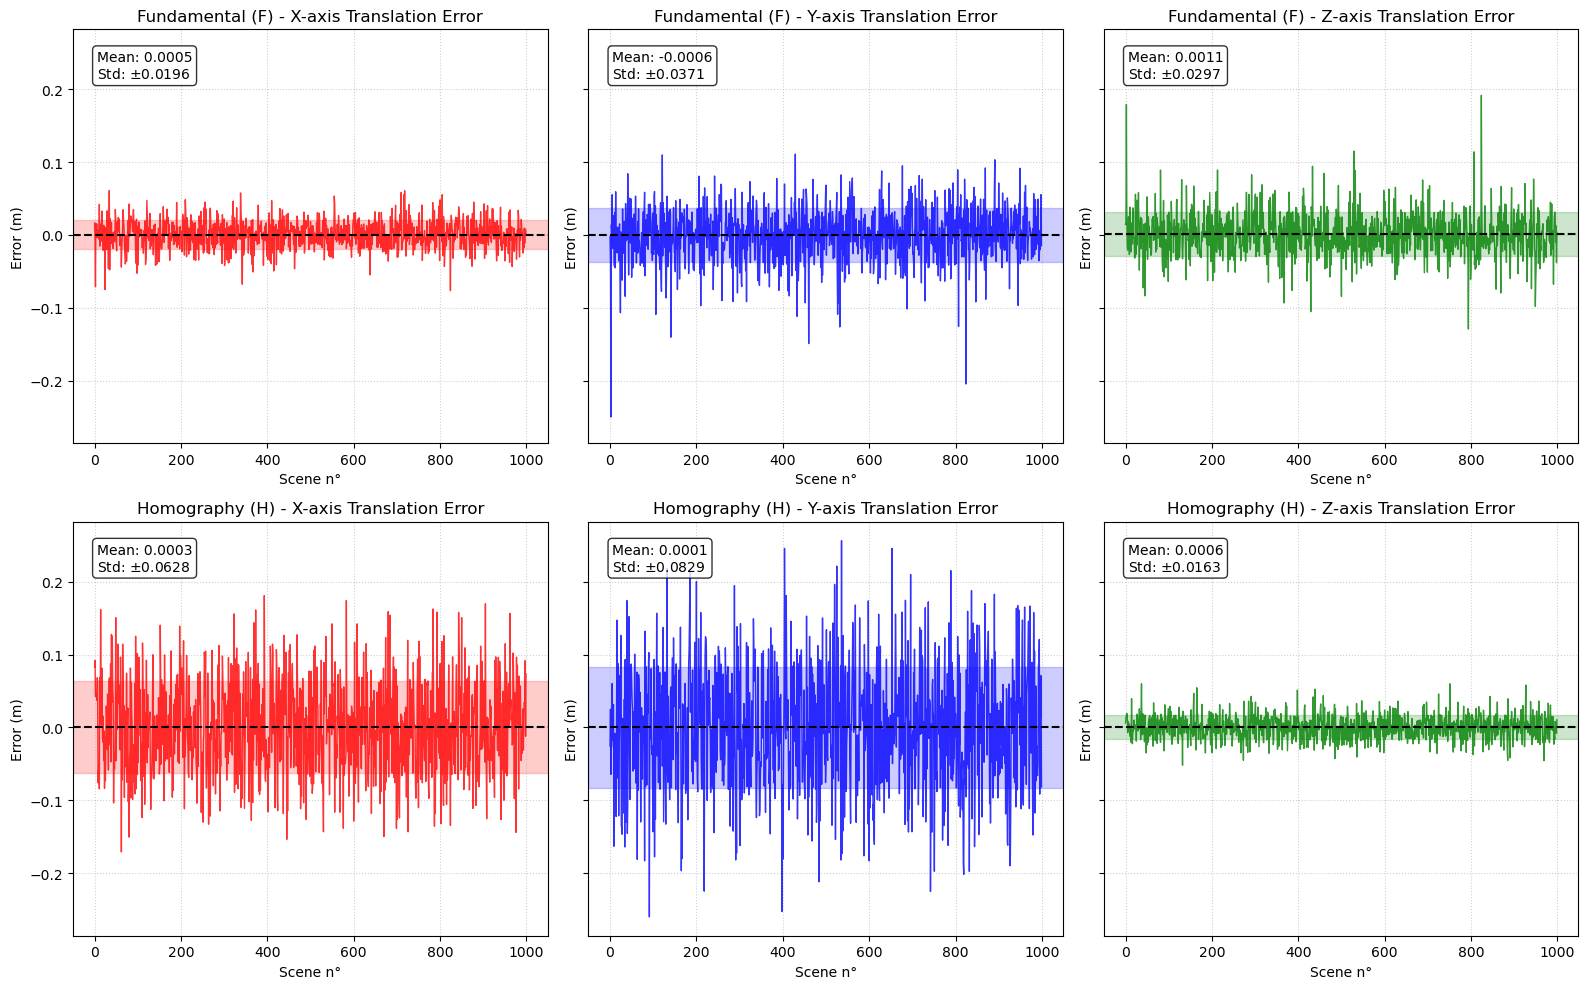

In [89]:
# 1. Calculate the error for each translation axis (Estimated - True)
# Arrays are shape (3, num_iterations)
err_t_F = t_est_F - t_true_arr
err_t_H = t_est_H - t_true_arr

# 2. Set up a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

labels = ['X-axis', 'Y-axis', 'Z-axis']
# Distinct colors for Translation to tell them apart from Rotation
colors_F = ['red', 'blue', 'green']
colors_H = ['red', 'blue', 'green']

# Loop through the 3 axes (tx=0, ty=1, tz=2)
for i in range(3):
    
    # ==========================================
    # ROW 1: FUNDAMENTAL MATRIX (F)
    # ==========================================
    ax_F = axes[0, i]
    
    # Filter NaNs for this specific axis
    valid_err_F = err_t_F[i, ~np.isnan(err_t_F[i])]
    mean_F, std_F = np.mean(valid_err_F), np.std(valid_err_F)
    
    # Plot
    ax_F.plot(err_t_F[i], color=colors_F[i], linewidth=1, alpha=0.8)
    ax_F.axhline(mean_F, color='black', linestyle='--', linewidth=1.5)
    ax_F.axhspan(mean_F - std_F, mean_F + std_F, color=colors_F[i], alpha=0.2)
    
    # Formatting
    ax_F.set_title(f'Fundamental (F) - {labels[i]} Translation Error')
    ax_F.set_xlabel('Scene n°')
    ax_F.set_ylabel('Error (m)')
    ax_F.grid(True, linestyle=':', alpha=0.6)
    
    # Stats Text Box
    ax_F.text(0.05, 0.95, f'Mean: {mean_F:.4f}\nStd: $\pm${std_F:.4f}', 
              transform=ax_F.transAxes, verticalalignment='top', 
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # ==========================================
    # ROW 2: HOMOGRAPHY MATRIX (H)
    # ==========================================
    ax_H = axes[1, i]
    
    # Filter NaNs for this specific axis
    valid_err_H = err_t_H[i, ~np.isnan(err_t_H[i])]
    mean_H, std_H = np.mean(valid_err_H), np.std(valid_err_H)
    
    # Plot
    ax_H.plot(err_t_H[i], color=colors_H[i], linewidth=1, alpha=0.8)
    ax_H.axhline(mean_H, color='black', linestyle='--', linewidth=1.5)
    ax_H.axhspan(mean_H - std_H, mean_H + std_H, color=colors_H[i], alpha=0.2)
    
    # Formatting
    ax_H.set_title(f'Homography (H) - {labels[i]} Translation Error')
    ax_H.set_xlabel('Scene n°')
    ax_H.set_ylabel('Error (m)')
    ax_H.grid(True, linestyle=':', alpha=0.6)
    
    # Stats Text Box
    ax_H.text(0.05, 0.95, f'Mean: {mean_H:.4f}\nStd: $\pm${std_H:.4f}', 
              transform=ax_H.transAxes, verticalalignment='top', 
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# Adjust the top margin slightly so the main suptitle doesn't overlap
plt.show()

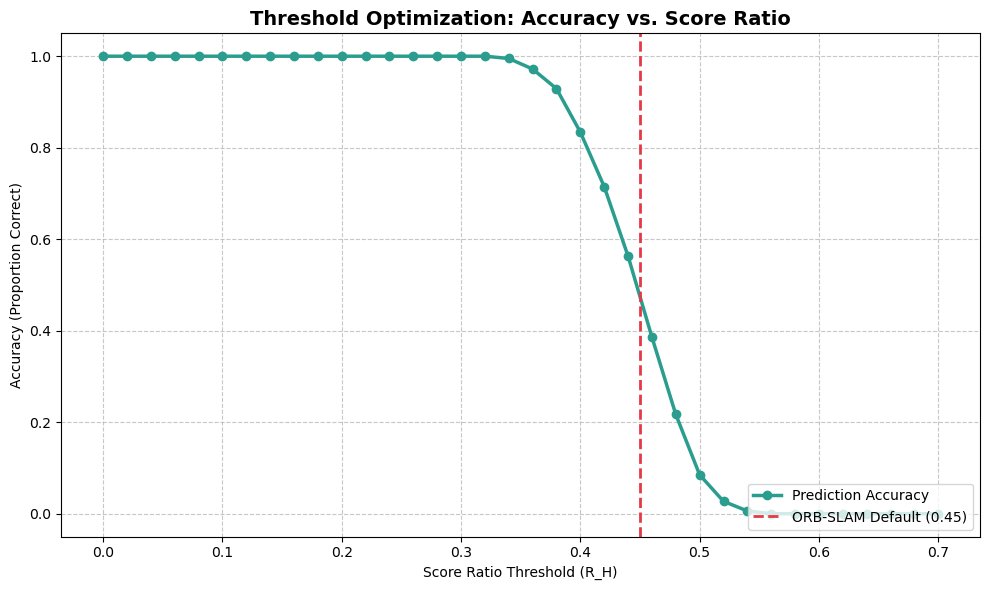

The mathematically optimal threshold for this dataset is: 0.00
Peak Accuracy: 100.00%
[1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    0.995 0.972 0.929 0.834 0.715 0.563 0.386
 0.217 0.085 0.027 0.006 0.    0.    0.    0.    0.    0.    0.    0.   ]


In [18]:
thresholds = np.arange(0, 0.71, 0.02)
accuracy = np.zeros(len(thresholds))

# enumerate automatically gives us an index (0, 1, 2...) and the threshold value
for idx, thresh in enumerate(thresholds):
    
    # 1. Ground Truth: H is geometrically better when its ERROR is LOWER than F's
    better_geo_H = res_H < res_F
    
    # 2. Algorithm Prediction: H is picked if the SCORE RATIO beats the threshold
    predicted_H_better = score_ratio > thresh
    
    # 3. Check where the prediction matches reality
    correct_predictions_mask = (predicted_H_better == better_geo_H)
    
    # 4. Calculate and save the accuracy for this specific threshold
    accuracy[idx] = np.sum(correct_predictions_mask) / len(correct_predictions_mask)

# --- Visualize the Optimization ---
plt.figure(figsize=(10, 6))

# Plot the accuracy curve
plt.plot(thresholds, accuracy, marker='o', linestyle='-', color='#2A9D8F', linewidth=2.5, label='Prediction Accuracy')

# Mark the ORB-SLAM default threshold for comparison
plt.axvline(x=0.45, color='#E63946', linestyle='--', linewidth=2, label='ORB-SLAM Default (0.45)')

# Formatting
plt.title('Threshold Optimization: Accuracy vs. Score Ratio', fontweight='bold', fontsize=14)
plt.xlabel('Score Ratio Threshold (R_H)')
plt.ylabel('Accuracy (Proportion Correct)')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

# Print the actual mathematical winner
best_idx = np.argmax(accuracy)
print(f"The mathematically optimal threshold for this dataset is: {thresholds[best_idx]:.2f}")
print(f"Peak Accuracy: {accuracy[best_idx] * 100:.2f}%")
print(accuracy)

In [27]:
errors_F = np.zeros(t_est_F.shape[1])
for i in range(t_est_F.shape[1]):
    errors_F[i] = np.linalg.norm(t_est_F[:, i] - t_true)
RMSE_ATE_F = np.sqrt(np.mean(errors_F**2))
errors_H = np.zeros(t_est_H.shape[1])
for i in range(t_est_H.shape[1]):
    errors_H[i] = np.linalg.norm(t_est_H[:, i] - t_true)
RMSE_ATE_H = np.sqrt(np.mean(errors_H**2))

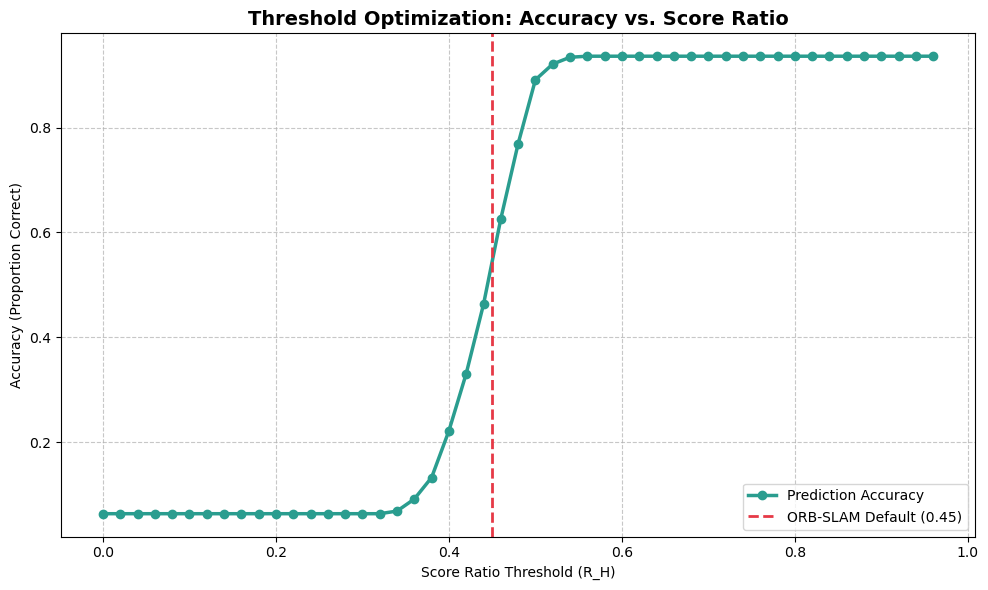

The mathematically optimal threshold for this dataset is: 0.56
Peak Accuracy: 93.60%
[0.064 0.064 0.064 0.064 0.064 0.064 0.064 0.064 0.064 0.064 0.064 0.064
 0.064 0.064 0.064 0.064 0.064 0.069 0.092 0.133 0.222 0.331 0.463 0.626
 0.769 0.891 0.921 0.934 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936
 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936
 0.936]


In [32]:
thresholds = np.arange(0, 0.98, 0.02)
accuracy = np.zeros(len(thresholds))

# enumerate automatically gives us an index (0, 1, 2...) and the threshold value
for idx, thresh in enumerate(thresholds):
    
    # 1. Ground Truth: H is geometrically better when its ERROR is LOWER than F's
    better_geo_H = errors_H < errors_F
    
    # 2. Algorithm Prediction: H is picked if the SCORE RATIO beats the threshold
    predicted_H_better = score_ratio > thresh
    
    # 3. Check where the prediction matches reality
    correct_predictions_mask = (predicted_H_better == better_geo_H)
    
    # 4. Calculate and save the accuracy for this specific threshold
    accuracy[idx] = np.sum(correct_predictions_mask) / len(correct_predictions_mask)

# --- Visualize the Optimization ---
plt.figure(figsize=(10, 6))

# Plot the accuracy curve
plt.plot(thresholds, accuracy, marker='o', linestyle='-', color='#2A9D8F', linewidth=2.5, label='Prediction Accuracy')

# Mark the ORB-SLAM default threshold for comparison
plt.axvline(x=0.45, color='#E63946', linestyle='--', linewidth=2, label='ORB-SLAM Default (0.45)')

# Formatting
plt.title('Threshold Optimization: Accuracy vs. Score Ratio', fontweight='bold', fontsize=14)
plt.xlabel('Score Ratio Threshold (R_H)')
plt.ylabel('Accuracy (Proportion Correct)')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

# Print the actual mathematical winner
best_idx = np.argmax(accuracy)
print(f"The mathematically optimal threshold for this dataset is: {thresholds[best_idx]:.2f}")
print(f"Peak Accuracy: {accuracy[best_idx] * 100:.2f}%")
print(accuracy)

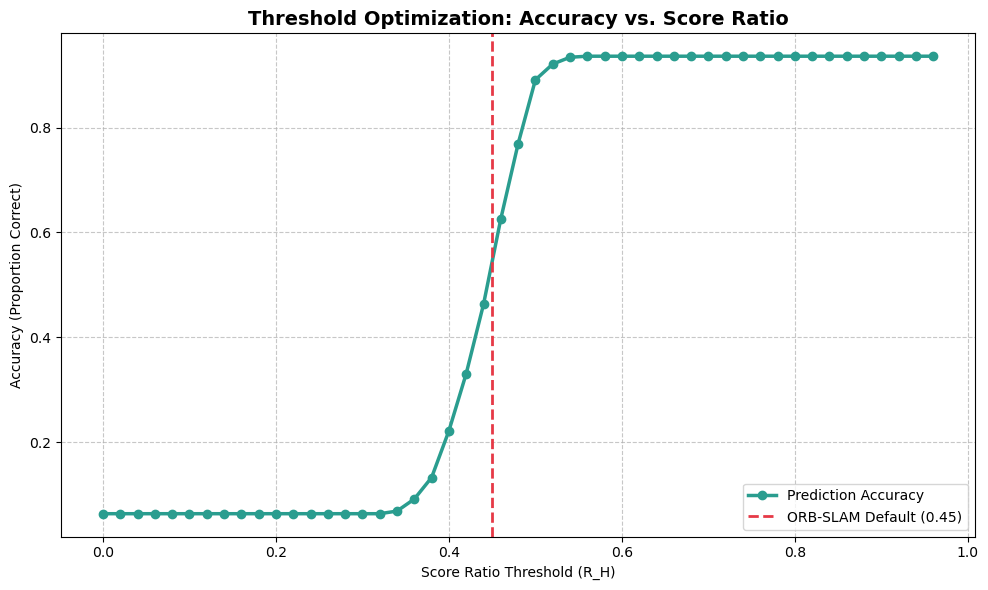

The mathematically optimal threshold for this dataset is: 0.56
Peak Accuracy: 93.60%
[0.064 0.064 0.064 0.064 0.064 0.064 0.064 0.064 0.064 0.064 0.064 0.064
 0.064 0.064 0.064 0.064 0.064 0.069 0.092 0.133 0.222 0.331 0.463 0.626
 0.769 0.891 0.921 0.934 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936
 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936 0.936
 0.936]


In [36]:
from scipy.spatial.transform import Rotation as R
def calculate_step_rre(true_angles, est_angles):
    """
    Calculates the Relative Rotation Error (RRE) in degrees.
    true_angles, est_angles: [rx, ry, rz] in degrees
    """
    # 1. Convert Euler angles to Rotation Matrices
    # Using 'xyz' or 'zyx' depending on your simulator's convention
    r_true = R.from_euler('xyz', true_angles, degrees=True).as_matrix()
    r_est = R.from_euler('xyz', est_angles, degrees=True).as_matrix()
    
    # 2. Compute the relative rotation matrix
    # This represents the "rotation difference"
    r_diff = np.dot(r_true.T, r_est)
    
    # 3. Calculate the angle of this rotation (the Geodesic distance)
    # Formula: acos((trace(R_diff) - 1) / 2)
    cos_theta = (np.trace(r_diff) - 1.0) / 2.0
    
    # Clip to avoid floating point errors outside [-1, 1]
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    
    return np.degrees(np.arccos(cos_theta))

error_F = np.zeros(angle_est_F.shape[1])
for i in range (angle_est_F.shape[1]):
    error_F[i] = calculate_step_rre(angle_true[:,0], angle_est_F[:,i])

error_H = np.zeros(angle_est_F.shape[1])
for i in range (angle_est_F.shape[1]):
    error_H[i] = calculate_step_rre(angle_true[:,0], angle_est_H[:,i])

thresholds = np.arange(0, 0.98, 0.02)
accuracy = np.zeros(len(thresholds))

# enumerate automatically gives us an index (0, 1, 2...) and the threshold value
for idx, thresh in enumerate(thresholds):
    .5
    # 1. Ground Truth: H is geometrically better when its ERROR is LOWER than F's
    better_geo_H = errors_H < errors_F
    
    # 2. Algorithm Prediction: H is picked if the SCORE RATIO beats the threshold
    predicted_H_better = score_ratio > thresh
    
    # 3. Check where the prediction matches reality
    correct_predictions_mask = (predicted_H_better == better_geo_H)
    
    # 4. Calculate and save the accuracy for this specific threshold
    accuracy[idx] = np.sum(correct_predictions_mask) / len(correct_predictions_mask)

# --- Visualize the Optimization ---
plt.figure(figsize=(10, 6))

# Plot the accuracy curve
plt.plot(thresholds, accuracy, marker='o', linestyle='-', color='#2A9D8F', linewidth=2.5, label='Prediction Accuracy')

# Mark the ORB-SLAM default threshold for comparison
plt.axvline(x=0.45, color='#E63946', linestyle='--', linewidth=2, label='ORB-SLAM Default (0.45)')

# Formatting
plt.title('Threshold Optimization: Accuracy vs. Score Ratio', fontweight='bold', fontsize=14)
plt.xlabel('Score Ratio Threshold (R_H)')
plt.ylabel('Accuracy (Proportion Correct)')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

# Print the actual mathematical winner
best_idx = np.argmax(accuracy)
print(f"The mathematically optimal threshold for this dataset is: {thresholds[best_idx]:.2f}")
print(f"Peak Accuracy: {accuracy[best_idx] * 100:.2f}%")
print(accuracy)